In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

file_name = "clean_df_Laptop.csv"
df = pd.read_csv(file_name, header=0, index_col=0)
df.dtypes
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Screen_Size_in,Weight_lb,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,35.56,0.551724,8,256,1.60,978,14.000000,3.52800,Low,False,True
1,Dell,3,1,1,3,39.62,0.689655,4,256,2.20,634,15.598425,4.85100,Low,True,False
2,Dell,3,1,1,7,39.62,0.931034,8,256,2.20,946,15.598425,4.85100,Low,True,False
3,Dell,4,2,1,5,33.78,0.551724,8,128,1.22,1244,13.299213,2.69010,Low,False,True
4,HP,4,2,1,7,39.62,0.620690,8,256,1.91,837,15.598425,4.21155,Low,True,False


In [2]:
# Task 1: Single Linear Regression

# In previous lab, we learnt that CPU_frequency is the parameter with the lowest p-value among the different features of the dataset.
# Create a single feature Linear Regression model that fits the pair of CPU_frequency and Price to find the model for prediction.
X = df[['CPU_frequency']]
Y = df['Price']

lm = LinearRegression()
lm.fit(X, Y) # train the model with CPU_frequency for price
Yhat = lm.predict(X) # get the prediction output Yhat for the actual data

Yhat[0:5] # display the first 5 values of the predicted values

array([1073.07834392, 1277.93263722, 1636.42765051, 1073.07834392,
       1175.50549057])

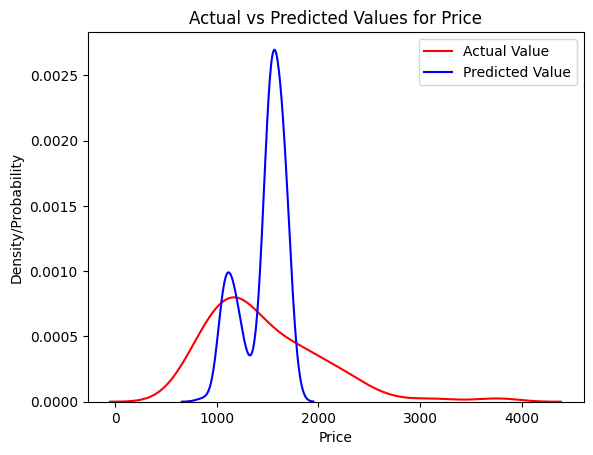

In [3]:
# Generate the Distribution plot for the predicted values and that of the actual values. How well did the model perform?

ax1 = sns.kdeplot(Y, color="r", label="Actual Value")
sns.kdeplot(Yhat, color="b", label="Predicted Value", ax=ax1)

plt.title('Actual vs Predicted Values for Price')
plt.xlabel('Price')
plt.ylabel('Density/Probability')
plt.legend()

plt.show()

# the model does not perform well, different shapes.



In [ ]:
# Evalueate the Mean Squared Error and R-square values for the model

print("Simple Linear Regression\n")

r_square = lm.score(X,Y) * 100
mse = mean_squared_error(Y, Yhat)

print(f"R-square = {r_square:.2f} %")
print(f"Mean Square Error = {mse:,.2f} \n")

print(f"{r_square:.2f} percent of the variation in price can be explained by the change in CPU_frequency.")
print(f"The remaining {(100-r_square):.2f} % of the price variation is due to other factors (RAM, GPU, brand, etc.) or random noise.\n")

rmse = np.sqrt(mse)
print(f"On average, the model's predictions are off by about $ {rmse:.2f}")


Simple Linear Regression

R-square = 13.44 %
Mean Square Error = 284,583.44 

13.44 percent of the variation in price can be explained by the change in CPU_frequency.
The remaining 86.56 % of the price variation is due to other factors (RAM, GPU, brand, etc.) or random noise.

On average, the model's predictions are off by about $ 533.46


In [5]:
# Task 2 : Multiple Features Linear Regression

# The features which have a low enough p-value so as to indicate strong relationship with the Price value are CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU, and Category.
# Use all these features to create a Multiple Linear Regression system.

lm2 = LinearRegression()
X2 = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']]
lm2.fit(X2, df['Price'])
Yhat2 = lm2.predict(X2)


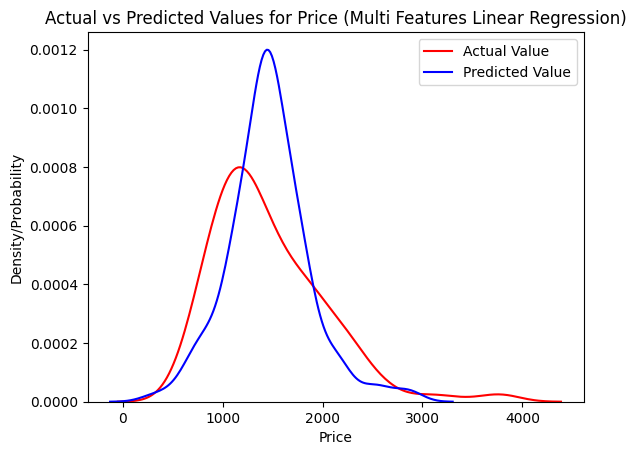

In [6]:
# Plot the Distribution graph of the predicted values as well as the Actual values

ax2 = sns.kdeplot(df['Price'], color="r", label="Actual Value")
sns.kdeplot(Yhat2, color="b", label="Predicted Value", ax=ax2)

plt.title('Actual vs Predicted Values for Price (Multi Features Linear Regression)')
plt.xlabel('Price')
plt.ylabel('Density/Probability')
plt.legend()

plt.show()
# the graph shows a much better fit than the Simple Single Feature Linear Regression model.

In [7]:
# Find the R-square and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?

print("Multi Features Linear Regression\n")

r_square2 = lm2.score(X2,df['Price']) * 100
mse2 = mean_squared_error(df['Price'], Yhat2)

print(f"R-square = {r_square2:.2f} %")
print(f"Mean Square Error = {mse2:,.2f} \n")

print(f"{r_square2:.2f} percent of the variation in price can be explained by the change in the given 7 features.")
print(f"The remaining {(100-r_square2):.2f} % of the price variation is due to other factors or random noise.\n")

rmse2 = np.sqrt(mse2)
print(f"On average, the model's predictions are off by about $ {rmse2:.2f}")

# Comparing to the Simple Regression model, this model has much higher percentage (increased from 13% to 51%) price prediction accuracy attributed to the 7 features.
# Also the average model's predictions price has lowered from $533 to $402.

Multi Features Linear Regression

R-square = 50.83 %
Mean Square Error = 161,680.57 

50.83 percent of the variation in price can be explained by the change in the given 7 features.
The remaining 49.17 % of the price variation is due to other factors or random noise.

On average, the model's predictions are off by about $ 402.10



Polynomial 1st Degree
 
1485 x + 253.7


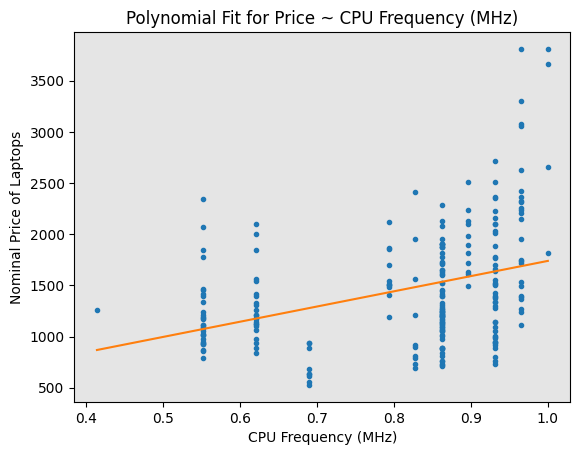

R-square = 13.44 %
Mean Square Error = 284,583.44 

13.44 percent of the variation in price can be explained by changes in CPU_frequency.
The remaining 86.56 % of the price variation is due to other factors or random noise.

On average, the model's predictions are off by about $ 533.46



Polynomial 3rd Degree
           3             2
3.409e+04 x - 6.574e+04 x + 4.129e+04 x - 7238


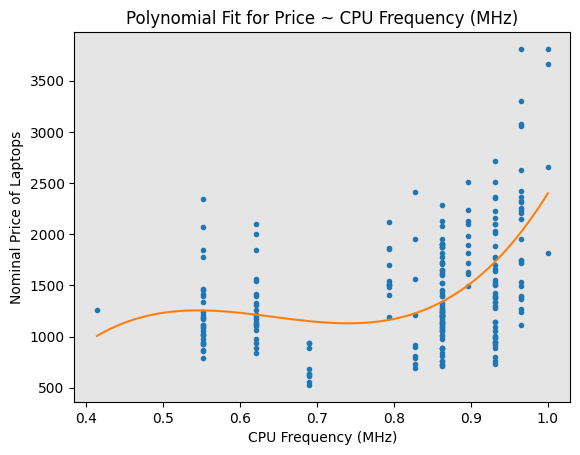

R-square = 26.69 %
Mean Square Error = 241,024.86 

26.69 percent of the variation in price can be explained by changes in CPU_frequency.
The remaining 73.31 % of the price variation is due to other factors or random noise.

On average, the model's predictions are off by about $ 490.94



Polynomial 5th Degree
           5            4             3             2
1.357e+06 x - 4.72e+06 x + 6.458e+06 x - 4.336e+06 x + 1.425e+06 x - 1.818e+05


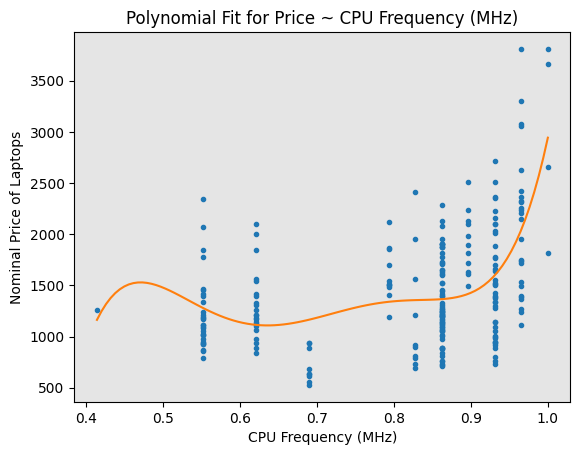

R-square = 30.31 %
Mean Square Error = 229,137.30 

30.31 percent of the variation in price can be explained by changes in CPU_frequency.
The remaining 69.69 % of the price variation is due to other factors or random noise.

On average, the model's predictions are off by about $ 478.68


In [ ]:
# Task 3 - Polynomial Regression

# Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Remember that polynomial fits are done using numpy.polyfit. 

# A graph plotting function that accept a model, result variables (Y), input features (X), and title label.
def PlotPolly(model, independent_variable, dependent_variable, Name):
    x_new = np.linspace(independent_variable.min(), independent_variable.max(), 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title(f"Polynomial Fit for Price ~ {Name}")
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Nominal Price of Laptops')

    plt.show()
    plt.close()


X3 = df['CPU_frequency']

# first degree
print("\nPolynomial 1st Degree")
f1 = np.polyfit(X3,df['Price'],1) # train the model
p1 = np.poly1d(f1) # create model function
print(p1)
PlotPolly(p1,X3,df['Price'],'CPU Frequency (MHz)')

r_square1 = r2_score(df['Price'], p1(X3)) * 100
mse1 = mean_squared_error(df['Price'], p1(X3))
print(f"R-square = {r_square1:.2f} %")
print(f"Mean Square Error = {mse1:,.2f} \n")
print(f"{r_square1:.2f} percent of the variation in price can be explained by changes in CPU_frequency.")
print(f"The remaining {(100-r_square1):.2f} % of the price variation is due to other factors or random noise.\n")
rmse1 = np.sqrt(mse1)
print(f"On average, the model's predictions are off by about $ {rmse1:.2f}")


# third degree
print("\n\n\nPolynomial 3rd Degree")
f3 = np.polyfit(X3,df['Price'],3) # train the model
p3 = np.poly1d(f3) # create model function
print(p3)
PlotPolly(p3,X3,df['Price'],'CPU Frequency (MHz)')

r_square3 = r2_score(df['Price'], p3(X3)) * 100
mse3 = mean_squared_error(df['Price'], p3(X3))
print(f"R-square = {r_square3:.2f} %")
print(f"Mean Square Error = {mse3:,.2f} \n")
print(f"{r_square3:.2f} percent of the variation in price can be explained by changes in CPU_frequency.")
print(f"The remaining {(100-r_square3):.2f} % of the price variation is due to other factors or random noise.\n")
rmse3 = np.sqrt(mse3)
print(f"On average, the model's predictions are off by about $ {rmse3:.2f}")


# fifth degree
print("\n\n\nPolynomial 5th Degree")
f5 = np.polyfit(X3,df['Price'],5) # train the model
p5 = np.poly1d(f5) # create model function
print(p5)
PlotPolly(p5,X3,df['Price'],'CPU Frequency (MHz)')

r_square5 = r2_score(df['Price'], p5(X3)) * 100
mse5 = mean_squared_error(df['Price'], p5(X3))
print(f"R-square = {r_square5:.2f} %")
print(f"Mean Square Error = {mse5:,.2f} \n")
print(f"{r_square5:.2f} percent of the variation in price can be explained by changes in CPU_frequency.")
print(f"The remaining {(100-r_square5):.2f} % of the price variation is due to other factors or random noise.\n")
rmse5 = np.sqrt(mse5)
print(f"On average, the model's predictions are off by about $ {rmse5:.2f}")

# While a curved line (Polynomial) is better than a straight line (SLR), it still insn't as powerful as using
# multiple features (MLR) which gave us that 51% r_square.

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])


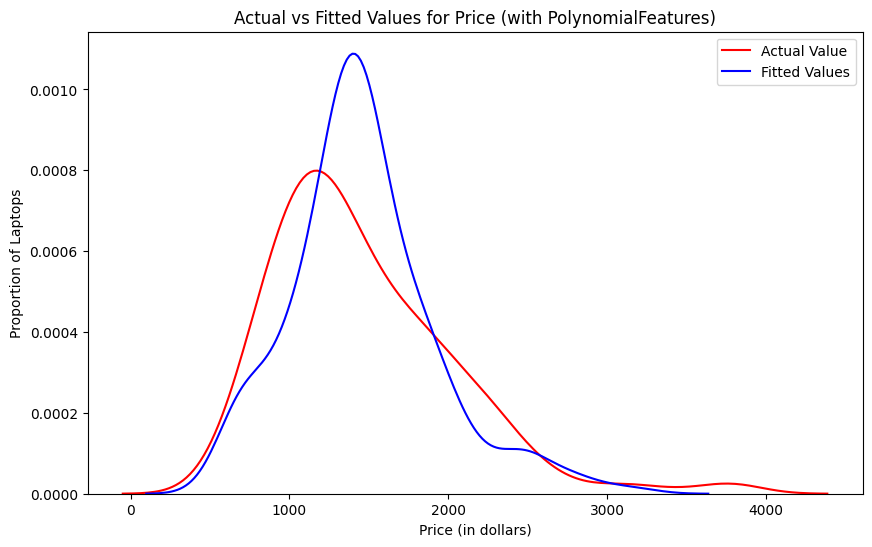

In [19]:
# Task 4 - Pipeline

# Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features as before to create this pipeline. 

X4 = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']]

Input = [('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe = Pipeline(Input)
print(pipe) 

X4 = X4.astype(float)
pipe.fit(X4,df['Price'])
ypipe = pipe.predict(X4)


# Plot the distribution of the Actual values vs Predicted values
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Price'], color="r", label="Actual Value") 
sns.kdeplot(ypipe, color="b", label="Fitted Values") 
plt.title('Actual vs Fitted Values for Price (with PolynomialFeatures)')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Laptops')
plt.legend()
plt.show()




In [21]:
# Evaluate the MSE and R^2 values for the this predicted output.

r_square = r2_score(df['Price'], ypipe) * 100
mse = mean_squared_error(df['Price'], ypipe)
print(f"R-square = {r_square:.2f} %")
print(f"Mean Square Error = {mse:,.2f} \n")
print(f"{r_square:.2f} percent of the variation in price can be explained by changes in the given features.")
print(f"The remaining {(100-r_square):.2f} % of the price variation is due to other factors or random noise.\n")
rmse = np.sqrt(mse)
print(f"On average, the model's predictions are off by about $ {rmse:.2f}")


R-square = 63.32 %
Mean Square Error = 120,595.86 

63.32 percent of the variation in price can be explained by changes in the given features.
The remaining 36.68 % of the price variation is due to other factors or random noise.

On average, the model's predictions are off by about $ 347.27
